In [ ]:
# NB : This reload your library after each edit, 
# so you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

## Imports

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# ML
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Loading Data

In [7]:
df_diamonds = sns.load_dataset('diamonds')

In [9]:
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [12]:
df_diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [14]:
df_diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Count'>

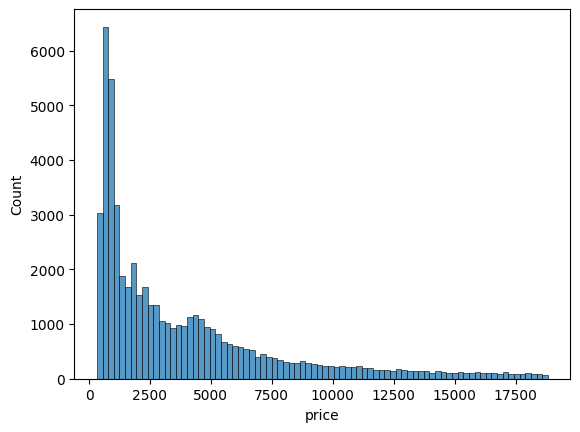

In [15]:
sns.histplot(data=df_diamonds,
             x="price")

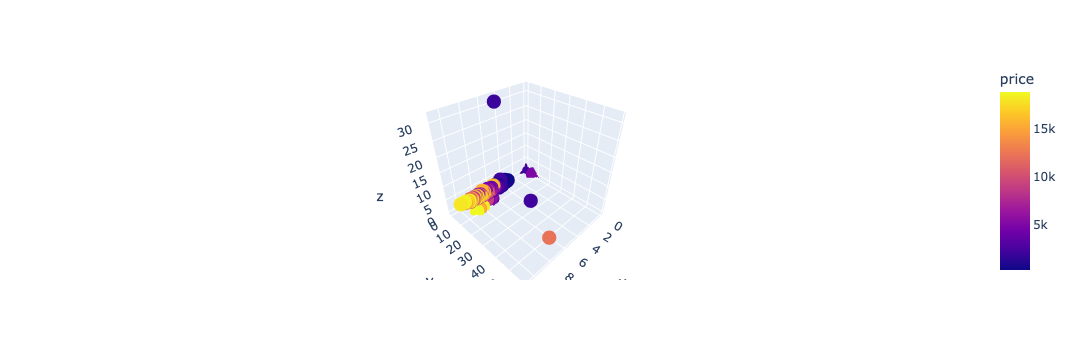

In [21]:
px.scatter_3d(data_frame=df_diamonds,
              x="x",y="y",z="z", color="price")

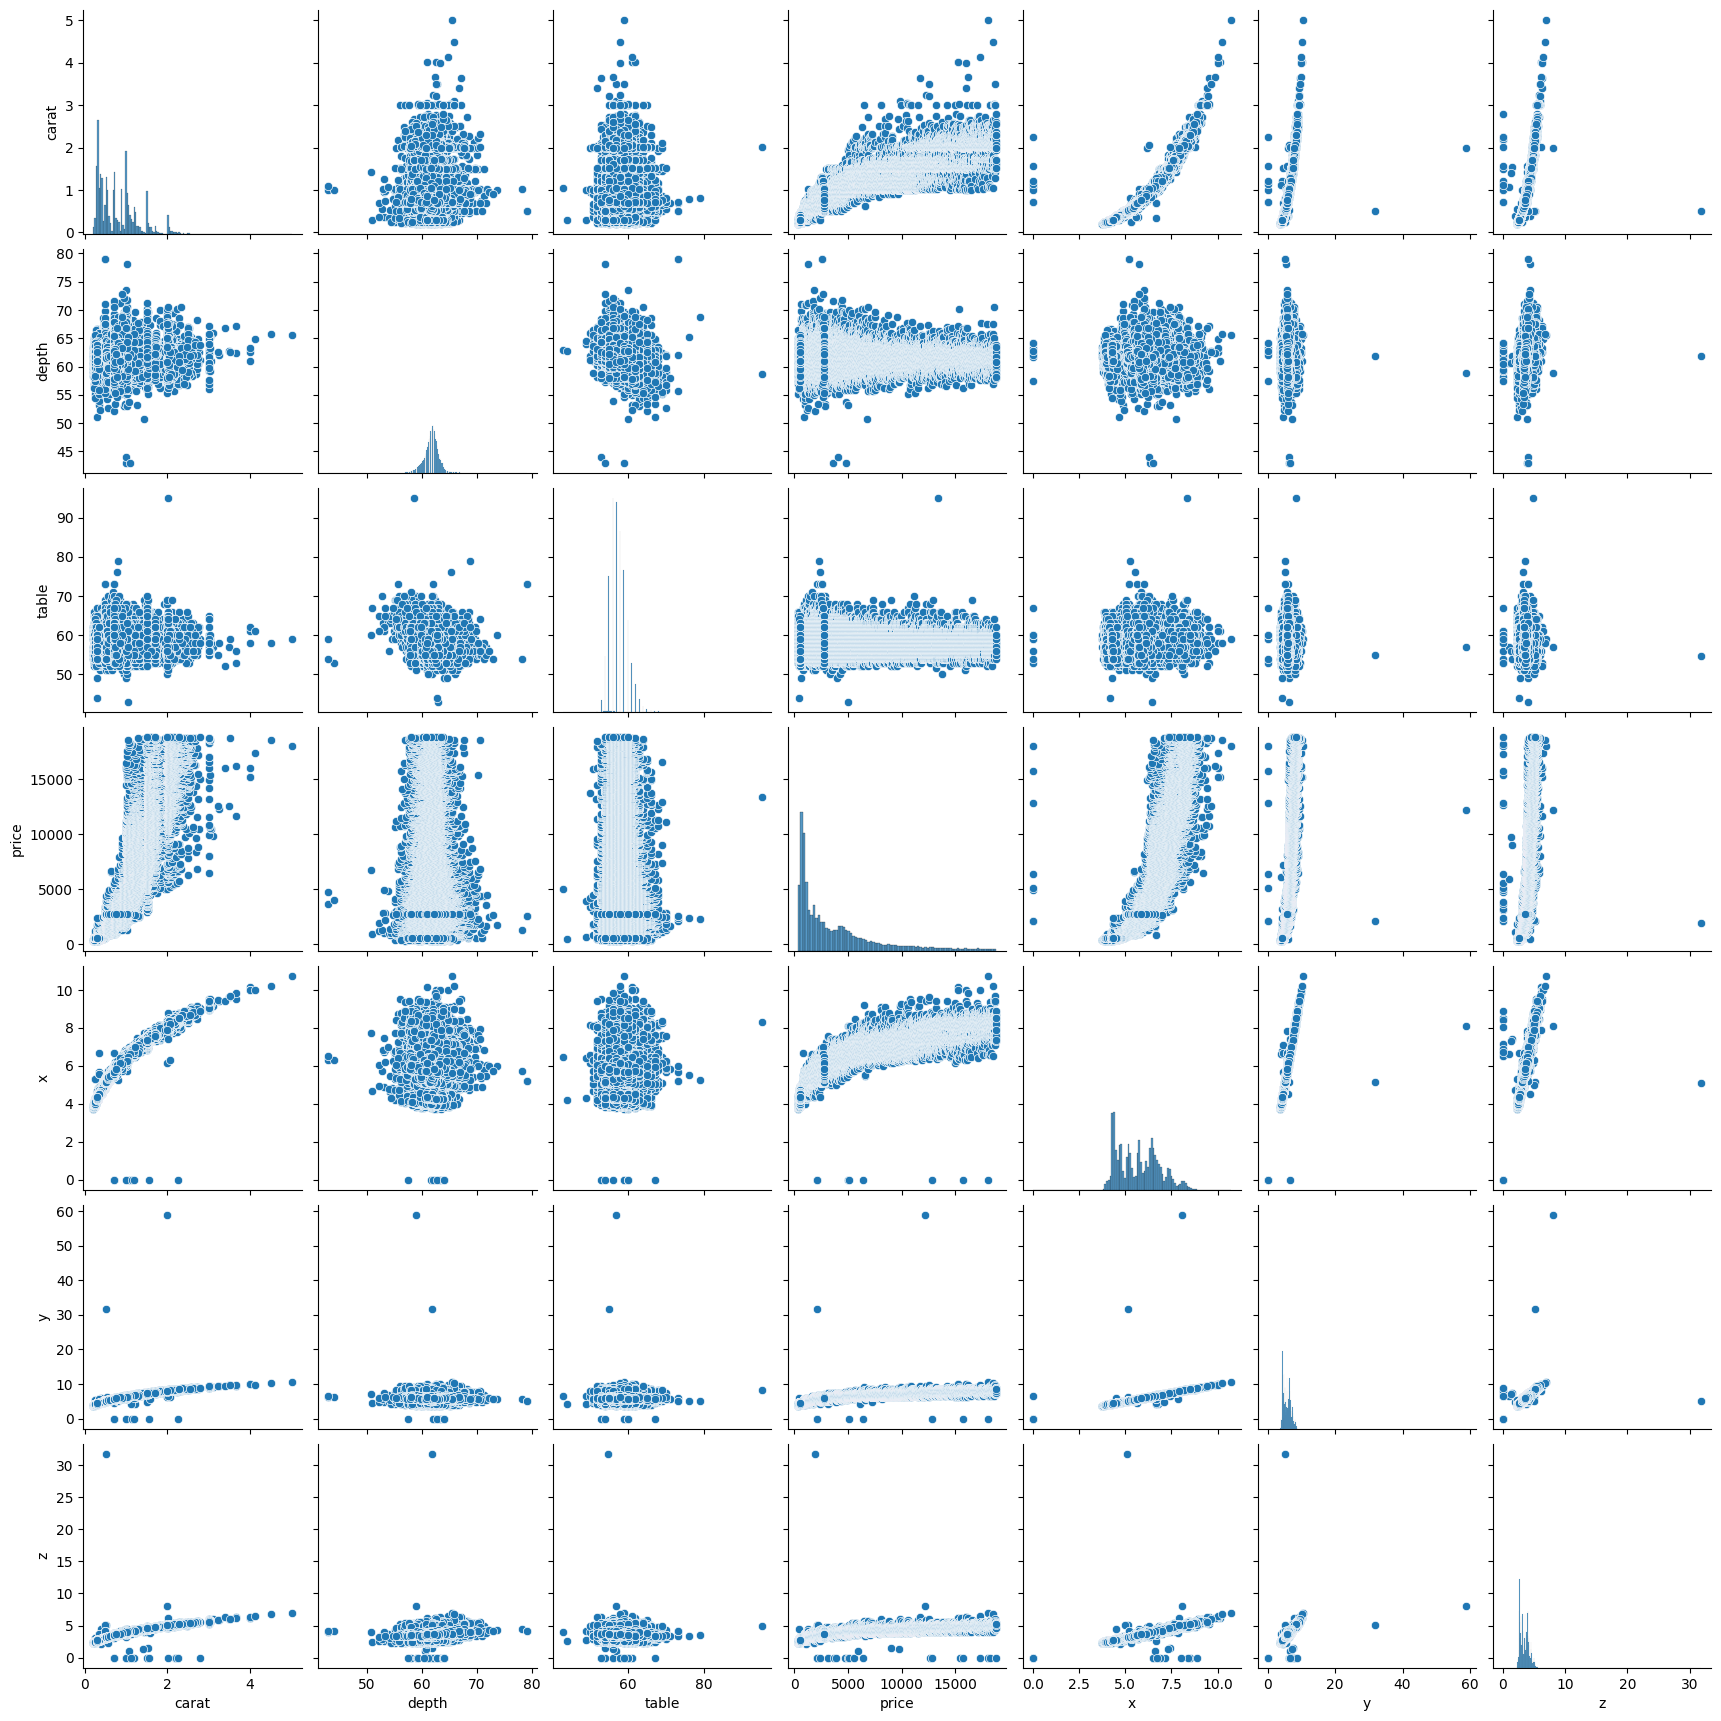

In [32]:
sns.pairplot(data=df_diamonds);

<Axes: >

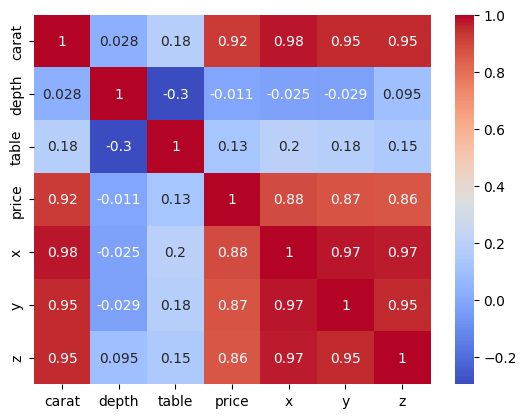

In [31]:
sns.heatmap(df_diamonds.select_dtypes(include="number").corr(),
           annot=True,
           cmap="coolwarm")

In [39]:
df_diamonds.select_dtypes(include="category")\
            ["color"].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [45]:
import scipy.stats as stats
groups = [group["price"].values for name, group in df_diamonds.groupby("color", observed=False)]


print("--- Test ANOVA à un facteur ---")
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"Statistique F : {f_stat:.2f}")
print(f"P-value       : {p_value_anova:.2e}")

if p_value_anova < 0.05:
    print("Conclusion : On rejette H0. La couleur a un impact significatif sur le prix moyen.\n")
else:
    print("Conclusion : On ne peut pas rejeter H0. La couleur ne semble pas impacter le prix.\n")

--- Test ANOVA à un facteur ---
Statistique F : 290.21
P-value       : 0.00e+00
Conclusion : On rejette H0. La couleur a un impact significatif sur le prix moyen.



## Data Cleaning

In [59]:
def keep_not_null(row) :
    if 0 in row.values : return False
    return True

# Pour le test sur une ligne :
keep_not_null(df_diamonds.loc[11182,:])
    

True

In [64]:
df_clean = df_diamonds[df_diamonds.apply(keep_not_null,axis=1)]

In [65]:
df_clean[df_clean["x"] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z


## Train Test Split

In [86]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["price"])
y = df_clean["price"]

X_train, X_test, y_train, y_test  = train_test_split(X,y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40440, 9), (13480, 9), (40440,), (13480,))

## Data Preprocessing
### Categorical Data

In [69]:
df_cat = df_clean.select_dtypes(include="category")
df_cat.describe()

,cut,color,clarity
count,53920,53920,53920
unique,5,7,8
top,Ideal,G,SI1
freq,21548,11284,13063


In [75]:
cat_pipe = Pipeline(
    [ ("cat_imp",SimpleImputer(strategy="most_frequent"))
      ,("ohe",OneHotEncoder(drop="first",sparse_output=False))
        ])
cat_pipe

,steps,"[('cat_imp', ...), ('ohe', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


### Numerical Data

In [79]:
num_pipe = Pipeline(
    [("knn_imp", KNNImputer(n_neighbors=5))
     ,("scaler", StandardScaler())
      ])
num_pipe
    

,steps,"[('knn_imp', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


## Final Preprocessor

In [89]:
preprocessor = ColumnTransformer(
    [("numeric",num_pipe, make_column_selector(dtype_include="number"))
    ,("categorical", cat_pipe, make_column_selector(dtype_exclude="number"))
      ]).set_output(transform="pandas")
preprocessor

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [93]:

# Normalement j'ai pas besoin de preproc mais pour vérfier 
preprocessor.fit(X_train)
X_train_scaled = preprocessor.transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

## Training 
### Trying a few models

In [98]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

df_clean["price"].max()

18823

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true,y_pred) -> dict[float] : 
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)
    r2  = r2_score(y_true,y_pred) 
    scores = {"mae":mae,"mse":mse,"r2":r2}
    print(scores)
    return scores
    

In [108]:
lin = LinearRegression()
lin.fit(X_train_scaled,y_train) 
y_pred = lin.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 722.4634689388907, 'mse': 1276242.2307746408, 'r2': 0.9188877100527478}


{'mae': 722.4634689388907, 'mse': 1276242.2307746408, 'r2': 0.9188877100527478}

In [109]:
forest = RandomForestRegressor()
forest.fit(X_train_scaled,y_train)
y_pred = forest.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 288.0732943113843, 'mse': 358129.5204486769, 'r2': 0.9772388776982629}


{'mae': 288.0732943113843, 'mse': 358129.5204486769, 'r2': 0.9772388776982629}

In [110]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled,y_train)
y_pred = knn.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 417.0560682492582, 'mse': 681395.902412463, 'r2': 0.9566935016937951}


{'mae': 417.0560682492582, 'mse': 681395.902412463, 'r2': 0.9566935016937951}

In [111]:
svm = SVR()
svm.fit(X_train_scaled,y_train)
y_pred = svm.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 1339.5945818836174, 'mse': 7871418.986713954, 'r2': 0.4997275566103807}


{'mae': 1339.5945818836174, 'mse': 7871418.986713954, 'r2': 0.4997275566103807}

In [113]:
! pip freeze | grep tensor

safetensors==0.6.2
tensorboard==2.20.0
tensorboard-data-server==0.7.2
tensorflow-datasets==4.9.9
tensorflow-estimator==2.15.0
tensorflow-io-gcs-filesystem==0.37.1
tensorflow-macos==2.15.1
tensorflow-metadata==1.17.2
tensorflow-metal==1.2.0


In [115]:
# Bonus : Deep Learning model with Tensorflow

## Optimizing Hyperparameters

In [122]:
from sklearn.model_selection import GridSearchCV

grid = {"n_neighbors": range(2,30)}


search = GridSearchCV(KNeighborsRegressor(), grid, verbose=1)

search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': range(2, 30)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [124]:
y_pred = search.predict(X_test_scaled)
print(search.best_params_)
evaluate_model(y_test,y_pred)

{'n_neighbors': 4}
{'mae': 417.14057863501483, 'mse': 672869.7432585312, 'r2': 0.9572353865153076}


{'mae': 417.14057863501483, 'mse': 672869.7432585312, 'r2': 0.9572353865153076}

In [127]:
grid = {"n_estimators": [100,150,300,500]
        #,"max_depth" : [None, 2,5,10]
        #,"min_samples_leaf" : [1,5,10,50]
       }

search = GridSearchCV(RandomForestRegressor(),grid,verbose=1, cv=3)
search.fit(X_train_scaled,y_train)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5; 1/4] START n_estimators=100............................................
[CV 1/5; 1/4] END .............n_estimators=100;, score=0.974 total time=  13.0s
[CV 2/5; 1/4] START n_estimators=100............................................
[CV 3/5; 1/4] END .............n_estimators=100;, score=0.974 total time=  49.4s
[CV 4/5; 1/4] START n_estimators=100............................................
[CV 4/5; 1/4] END .............n_estimators=100;, score=0.974 total time=   9.7s
[CV 5/5; 1/4] START n_estimators=100............................................
[CV 5/5; 1/4] END .............n_estimators=100;, score=0.973 total time=   8.7s
[CV 1/5; 2/4] START n_estimators=150............................................
[CV 1/5; 2/4] END .............n_estimators=150;, score=0.974 total time=  13.1s
[CV 2/5; 2/4] START n_estimators=150............................................
[CV 2/5; 2/4] END .............n_estimators=150;,

,estimator,RandomForestRegressor()
,param_grid,"{'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [128]:
y_pred = search.predict(X_test_scaled)
print(search.best_params_)
evaluate_model(y_test,y_pred)

{'n_estimators': 500}
{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}


{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}

### Final Train

In [133]:
forest = RandomForestRegressor(**search.best_params_)
forest.fit(X_train_scaled,y_train)
y_pred = forest.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}


{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}

## Saving Model

In [134]:
import pickle 
import os 

In [137]:
! ls

Exploration.ipynb models


In [140]:
# Saving the preprocessor 
model_path = "models"
if not os.path.exists(model_path) : 
    os.mkdir(model_path)
with open(os.path.join(model_path,"preproc.pkl"),"wb") as f:
    pickle.dump(preprocessor,f)

In [141]:
# Saving the model 
with open(os.path.join(model_path,"model.pkl"),"wb")  as f:
    pickle.dump(forest,f)

In [142]:
! tree

.
├── Exploration.ipynb
└── models
    ├── model.pkl
    └── preproc.pkl

2 directories, 3 files


## NB : Loading model

In [144]:
with open(os.path.join(model_path,"preproc.pkl"),"rb")  as f:
    new_preproc = pickle.load(f)
new_preproc

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
